Install dependencies

In [1]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 147.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


Import libraries

In [2]:
import ultralytics
print(ultralytics.__version__)

from ultralytics import YOLO
from roboflow import Roboflow


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.40


Download Dataset

In [3]:
from requests import api
from roboflow import Roboflow
from google.colab import userdata
api_key = userdata.get('SEGMENTATION')
rf = Roboflow(api_key=api_key)
project = rf.workspace("samarths-workspace-onsk6").project("indian-currency-segmentation")
version = project.version(3)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indian-Currency-Segmentation-3 in coco-segmentation:: 100%|██████████| 332/332 [00:00<00:00, 5227.31it/s]


COCO to YOLOv8 Conversion

In [4]:
import json
import os

def coco_to_yolo(json_path, output_dir):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Create mapping: COCO category_id -> YOLO class_index

    real_cats = [cat for cat in data['categories'] if cat['supercategory'] != 'none']
    categories = {cat['id']: i for i, cat in enumerate(real_cats)}

    # Create mapping: image_id -> image_info (width, height, file_name)
    images = {img['id']: img for img in data['images']}

    # Group annotations by image_id
    annotations_by_image = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)

    os.makedirs(output_dir, exist_ok=True)

    for img_id, anns in annotations_by_image.items():
        img_info = images[img_id]
        w, h = img_info['width'], img_info['height']
        filename = os.path.splitext(img_info['file_name'])[0] + '.txt'

        with open(os.path.join(output_dir, filename), 'w') as f:
            for ann in anns:
                cat_id = categories[ann['category_id']]
                # COCO polygons are [x1, y1, x2, y2, ...].
                # Assumes single polygon list structure.
                segmentation = ann['segmentation'][0]

                # Normalize coordinates
                normalized_coords = []
                for i in range(0, len(segmentation), 2):
                    normalized_coords.append(str(segmentation[i] / w))
                    normalized_coords.append(str(segmentation[i+1] / h))

                line = f"{cat_id} " + " ".join(normalized_coords)
                f.write(line + "\n")

if __name__ == "__main__":
    coco_to_yolo('/content/Indian-Currency-Segmentation-3/train/_annotations.coco.json', 'labels')

Split Dataset

In [6]:
import os
import shutil
import random

def split_data(image_dir, label_dir, output_base, split_ratios=(0.7, 0.2, 0.1)):
  # validating directories
  if not os.path.exists(image_dir):
    print(f"Error: Image directory does not exist: {image_dir}")
    return

  elif not os.path.exists(label_dir):
    print(f"Error: Label directory does not exist: {label_dir}")
    return

  # getting all the images
  files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  random.shuffle(files)

  # calculate the split indice
  n = len(files)
  train_idx = int(n * split_ratios[0])
  val_idx = train_idx + int(n * split_ratios[1])

  splits = {
      'train': files[:train_idx],
      'val': files[train_idx:val_idx],
      'test': files[val_idx:]
  }

  print(f"Total images found {n}")

  for split_name, file_list in splits.items():
    # Create directories
    target_img_dir = os.path.join(output_base, split_name, 'images')
    target_lbl_dir = os.path.join(output_base, split_name, 'labels')
    os.makedirs(target_img_dir, exist_ok=True)
    os.makedirs(target_lbl_dir, exist_ok=True)

    for filename in file_list:
      # copy images
      src_img = os.path.join(image_dir, filename)
      dst_img = os.path.join(target_img_dir, filename)
      shutil.copy2(src_img, dst_img)

      # Copy label
      base_name = os.path.splitext(filename)[0]
      label_filename = base_name + '.txt'
      src_label = os.path.join(label_dir, label_filename)
      dst_label = os.path.join(target_lbl_dir, label_filename)

      if os.path.exists(src_label):
          shutil.copy2(src_label, dst_label)
      else:
          # This helps identify if a file is truly missing or just misplaced
          print(f"Warning: Label missing for {filename}. Looked at: {src_label}")

  print("Dataset splitting complete.")

if __name__ == "__main__":
  split_data(image_dir='/content/Indian-Currency-Segmentation-3/train/',
             label_dir='/content/Indian-Currency-Segmentation-3/labels',
             output_base='/content/dataset'
             )

Total images found 329
Dataset splitting complete.


Verifying the split dataset against the label

In [7]:
import os
for split in ['train', 'val', 'test']:
    img_count = len(os.listdir(f'/content/dataset/{split}/images'))
    lbl_count = len(os.listdir(f'/content/dataset/{split}/labels'))
    print(f"{split}: {img_count} images, {lbl_count} labels")

train: 230 images, 230 labels
val: 65 images, 65 labels
test: 34 images, 34 labels


In [8]:
# Check a label file - should show class 0-6 only
import random
label_files = os.listdir('/content/dataset/train/labels')
sample = random.choice(label_files)
with open(f'/content/dataset/train/labels/{sample}') as f:
    print(f.read())

0 0.27439814814814817 0.6841111111111111 0.32814814814814813 0.7411597222222222 0.3375763888888889 0.7487037037037036 0.4106550925925926 0.8330972222222223 0.4233842592592592 0.8439421296296297 0.4285717592592593 0.8448842592592593 0.43941435185185185 0.8387546296296295 0.4724189814814815 0.8071666666666667 0.6548796296296296 0.6124467592592593 0.6567662037037038 0.6077314814814815 0.6619513888888889 0.6049027777777778 0.6760972222222222 0.5912314814814815 0.7142847222222223 0.5492685185185185 0.7241875 0.5412546296296297 0.7930231481481482 0.47006018518518516 0.8392268518518519 0.4181990740740741 0.8453564814814816 0.4101828703703704 0.8462986111111112 0.40405555555555556 0.8439421296296297 0.4002824074074074 0.8316828703703704 0.39368287037037036 0.8109375 0.3785949074074074 0.7543611111111111 0.3328611111111111 0.728900462962963 0.3097592592592593 0.6996689814814815 0.2795856481481482 0.6614814814814814 0.2380949074074074 0.6539375 0.22772222222222224 0.6478078703703704 0.2281944444

Create data.yaml

In [12]:
yaml_content = """
train: /content/dataset/train/images
val: /content/dataset/val/images
test: /content/dataset/test/images

nc: 7
names: ['Rs10', 'Rs100', 'Rs20', 'Rs200', 'Rs2000', 'Rs50', 'Rs500']
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

Train model

In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")  # n = nano, smallest/fastest
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    device=0,
    patience=10  # stops if no improvement for 10 epochs
)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, 

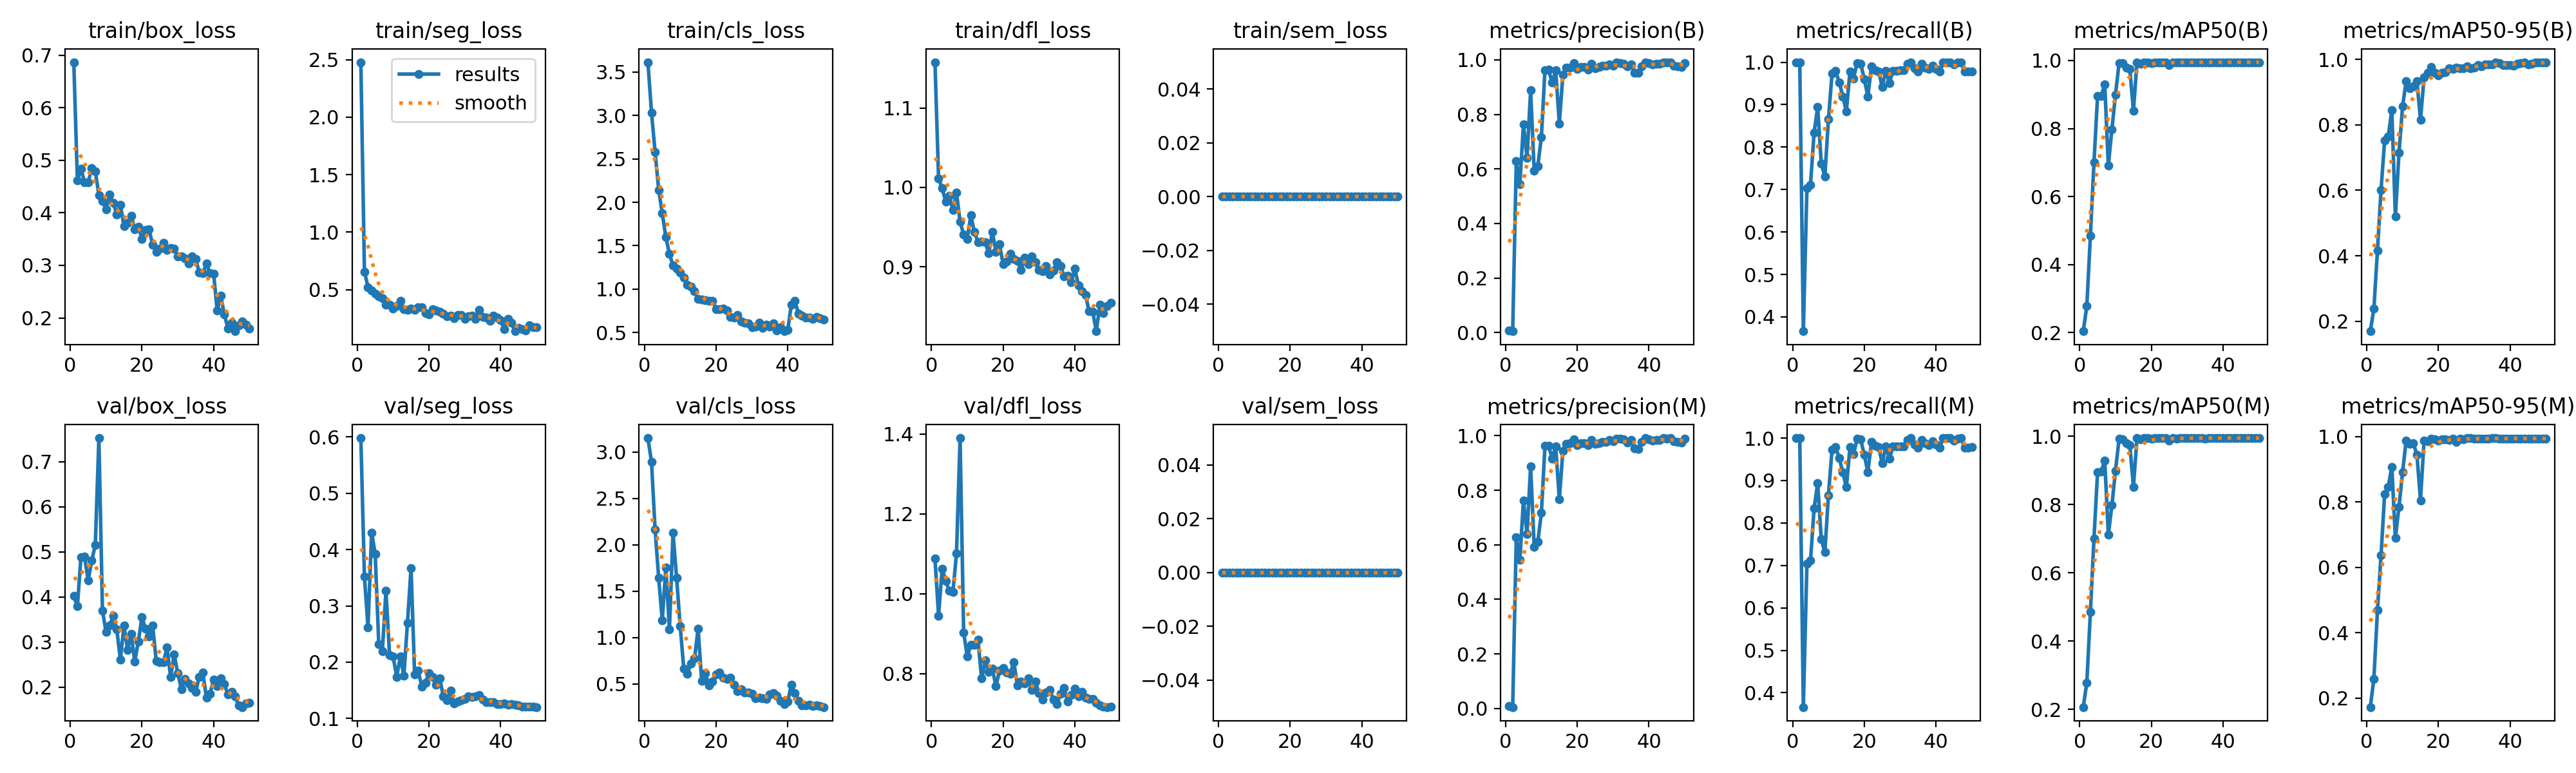

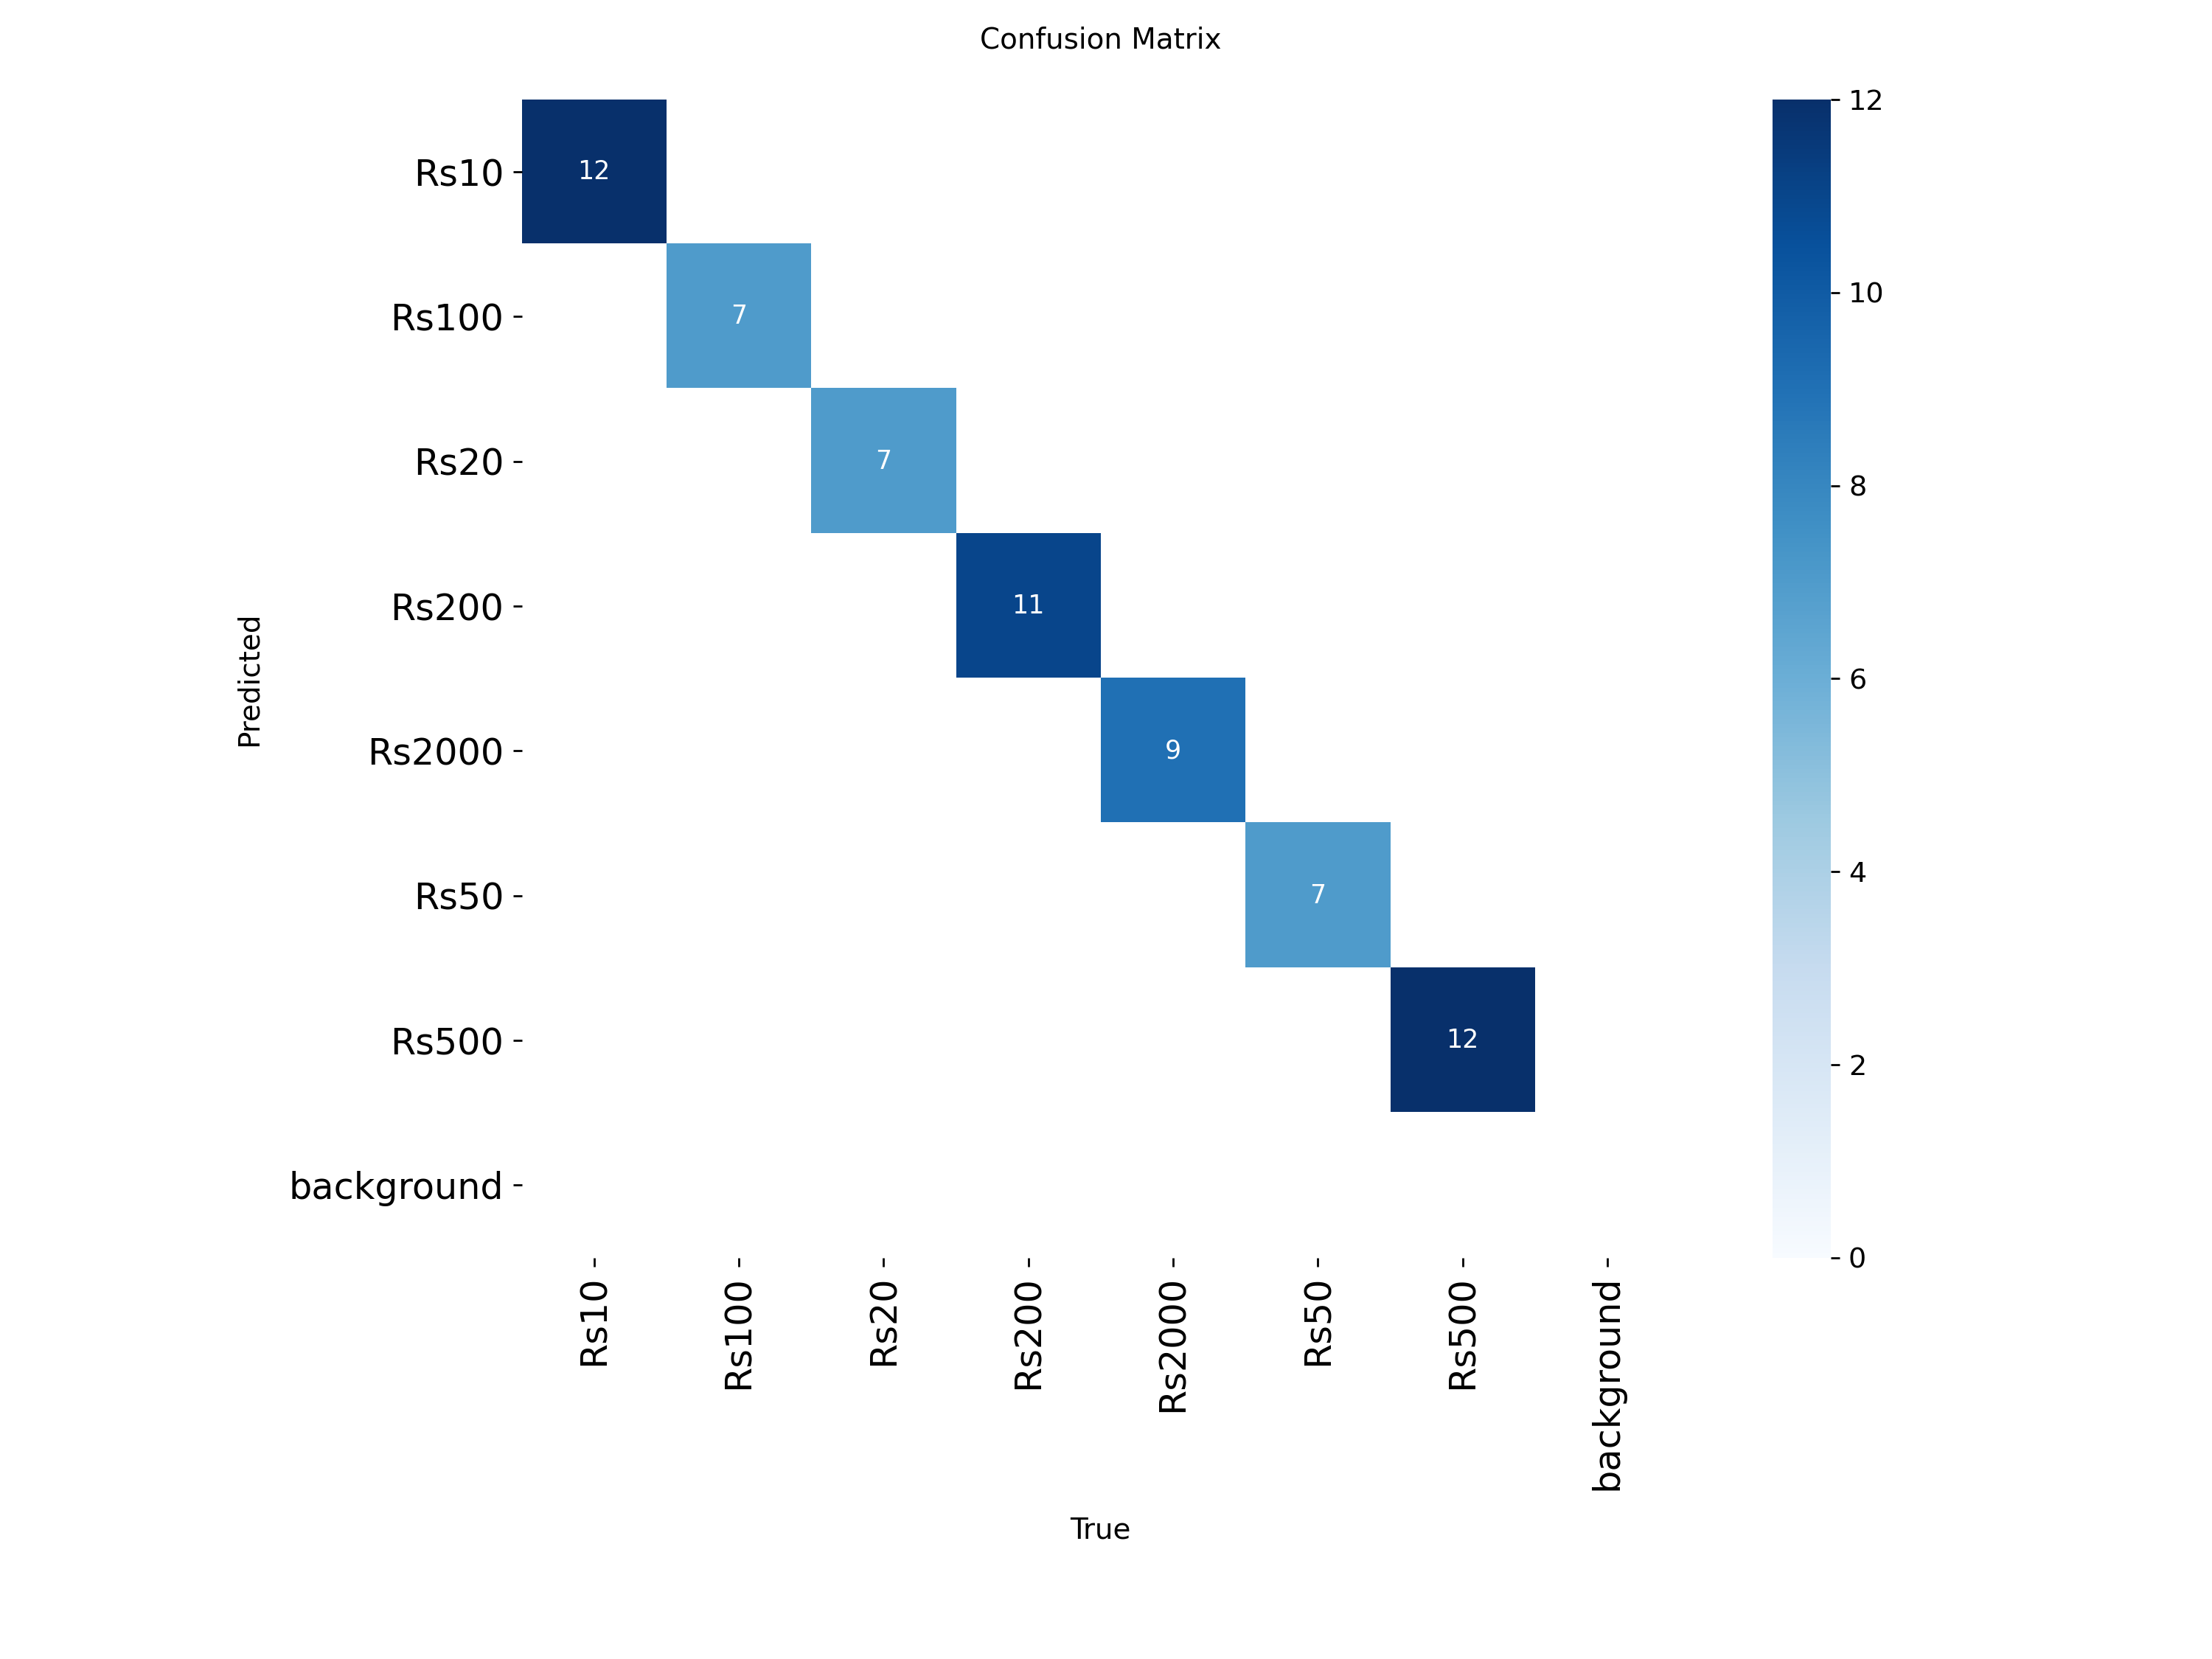

    epoch     time  train/box_loss  train/seg_loss  train/cls_loss  \
45     46  302.606         0.17469         0.15394         0.67219   
46     47  308.078         0.18638         0.14567         0.66043   
47     48  314.788         0.19331         0.18939         0.67814   
48     49  320.301         0.18686         0.17513         0.66275   
49     50  326.830         0.18006         0.17189         0.65397   

    train/dfl_loss  train/sem_loss  metrics/precision(B)  metrics/recall(B)  \
45         0.81868               0               0.99110            0.99873   
46         0.85177               0               0.97859            1.00000   
47         0.84179               0               0.97596            0.97774   
48         0.85049               0               0.97433            0.97734   
49         0.85450               0               0.98789            0.97835   

    metrics/mAP50(B)  ...  metrics/mAP50(M)  metrics/mAP50-95(M)  \
45             0.995  ...           

In [21]:
from IPython.display import Image, display

# Display the main results chart
display(Image(filename='/content/runs/segment/train-5/results.png'))
print("\n")

# Display the confusion matrix
display(Image(filename='/content/runs/segment/train-5/confusion_matrix.png'))

import pandas as pd

# Load the training results
df = pd.read_csv('/content/runs/segment/train-5/results.csv')

# Print the last few rows to see final performance
print(df.tail())

Inference

In [22]:
from ultralytics import YOLO

# 1. Load your custom trained model
model = YOLO('/content/runs/segment/train-5/weights/best.pt')

# 2. Run inference on a new image
# The 'save=True' argument will automatically save the annotated image to 'runs/detect/predict'
results = model.predict(source='/content/test.jpg', save=True, conf=0.5)

# 3. View the results (optional: if you want to inspect them in the notebook)
from PIL import Image
for r in results:
    im_array = r.plot()  # plot results BGR
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    im.show()  # display via PIL


image 1/1 /content/test.jpg: 640x640 1 Rs20, 9.3ms
Speed: 4.4ms preprocess, 9.3ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict


In [24]:
print(results[0].masks)

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0', dtype=torch.uint8)
orig_shape: (1067, 1067)
shape: torch.Size([1, 640, 640])
xy: [array([[     385.12,      176.72],
       [     385.12,      181.72],
       [     376.78,      190.06],
       [     375.12,      190.06],
       [     366.78,       198.4],
       [     365.11,       198.4],
       [     358.45,      205.06],
       [     356.78,      205.06],
       [     348.44,       213.4],
       [     346.77,       213.4],
       [      335.1,      225.07],
       [     333.44,      225.07],
       [      315.1,      243.41],
       [     313.43,      243.41],
       [     300.09,      256.75],
       [     298.43,      256.75],
       [     288.42,      266.75],
       [     286


image 1/1 /content/test.jpg: 640x640 1 Rs20, 10.0ms
Speed: 2.8ms preprocess, 10.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


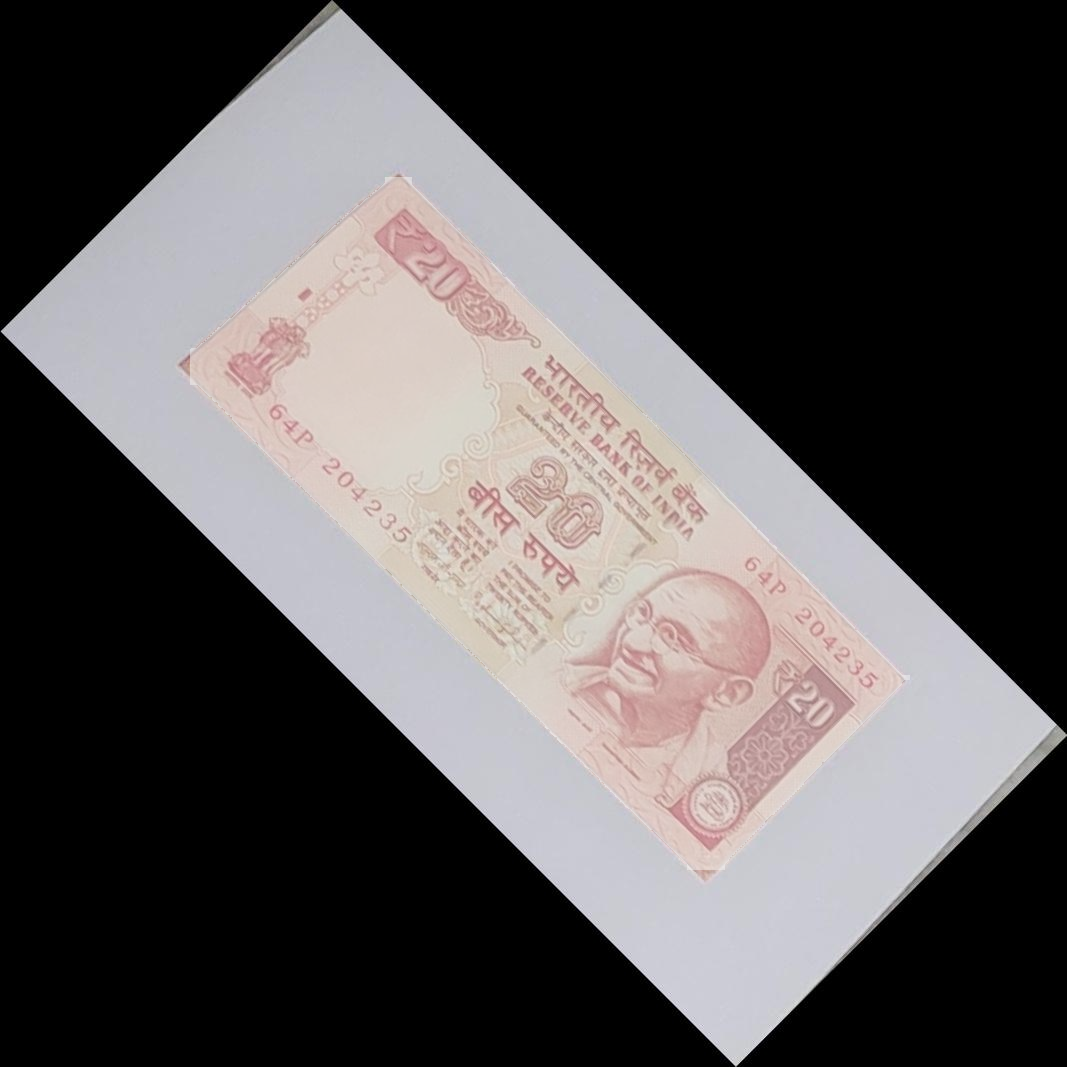

In [30]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

model = YOLO('/content/runs/segment/train-5/weights/best.pt')

results = model.predict(source='/content/test.jpg', conf=0.5)

for r in results:
    im_array = r.plot(masks=True, boxes=False, conf=True)
    im = Image.fromarray(im_array[..., ::-1])
    display(im)

In [38]:
model = YOLO('/content/runs/segment/train-5/weights/best.pt')
results = model.predict(
    source='/content/dataset/test/images/',
    conf=0.5,
    save=True
)


image 1/34 /content/dataset/test/images/100_108_jpg.rf.6081ad407f6078a9f4438cf54fa09210.jpg: 640x640 1 Rs100, 10.2ms
image 2/34 /content/dataset/test/images/100_122_45_jpg.rf.c0fa289a0c11e4e7aec5de5c340918d9.jpg: 640x640 1 Rs100, 9.2ms
image 3/34 /content/dataset/test/images/100_128_45_jpg.rf.1fb708f1d75fb6a33138b2244041ce83.jpg: 640x640 1 Rs100, 9.2ms
image 4/34 /content/dataset/test/images/100_137_45_jpg.rf.d572ea15123822dd58f7a4f4a000d91e.jpg: 640x640 1 Rs100, 9.2ms
image 5/34 /content/dataset/test/images/100_152_45_jpg.rf.04e9ea81265288860a79c22bd86d0b0c.jpg: 640x640 1 Rs100, 9.2ms
image 6/34 /content/dataset/test/images/100_40_jpg.rf.de3b0087bd70bc399329f60ddddaa416.jpg: 640x640 1 Rs100, 9.2ms
image 7/34 /content/dataset/test/images/100_40_jpg.rf.f8f96eda4847117f378162e6048afa3b.jpg: 640x640 1 Rs100, 9.1ms
image 8/34 /content/dataset/test/images/10_100_b_jpg.rf.65d86866d7c23c26df8eea662d9dac86.jpg: 640x640 1 Rs10, 9.1ms
image 9/34 /content/dataset/test/images/10_110_315_jpg.rf.68

['10_100_b_jpg.rf.65d86866d7c23c26df8eea662d9dac86.jpg', '10_133_jpg.rf.7d132243ff2dec5f007e36b0bd841511.jpg', '200_57_45_jpg.rf.dfd7acf126468d49b335ee9975be5dd1.jpg', '500_55_jpg.rf.e6ce92832d5e4eeeedc990ab6259b274.jpg', '10_110_315_jpg.rf.68bfdc02091a00e38c92374e01c813fb.jpg']


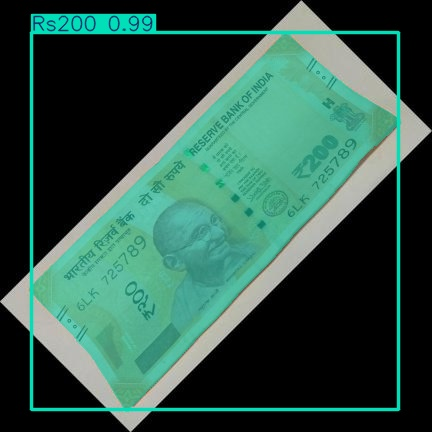

In [49]:
from IPython.display import Image as IPImage
import os

predict_dir = '/content/runs/segment/predict-3'  # change if different
images = os.listdir(predict_dir)
print(images[:5])  # show first 5 filenames

# Display first image
IPImage(filename=f'{predict_dir}/{images[2]}')

In [50]:
model = YOLO('/content/runs/segment/train-5/weights/best.pt')
results = model.predict(
    source='/content/Screenshot 2026-04-21 133527.png',
    conf=0.5,
    save=True
)


image 1/1 /content/Screenshot 2026-04-21 133527.png: 544x640 2 Rs50s, 49.9ms
Speed: 2.1ms preprocess, 49.9ms inference, 2.2ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/segment/predict-4


['Screenshot 2026-04-21 133527.jpg']


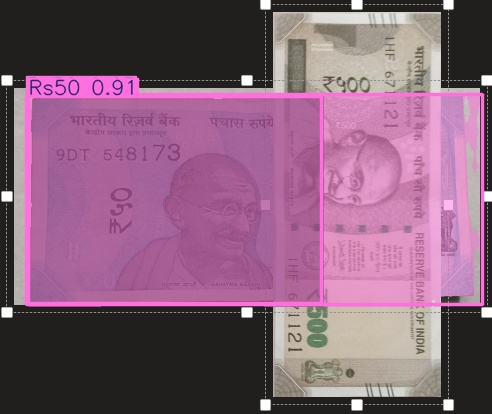

In [52]:
from IPython.display import Image as IPImage
import os

predict_dir = '/content/runs/segment/predict-4'  # change if different
images = os.listdir(predict_dir)
print(images[:5])  # show first 5 filenames

# Display first image
IPImage(filename=f'{predict_dir}/{images[0]}')

Evaluation

In [53]:
metrics = model.val(data='/content/dataset/data.yaml')
print(metrics.box.map50)   # mAP50 detection
print(metrics.seg.map50)   # mAP50 segmentation

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 562.5±192.0 MB/s, size: 16.5 KB)
val: Scanning /content/dataset/val/labels.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 13.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0it/s 4.8s
                   all         65         65      0.991          1      0.995      0.991      0.991          1      0.995      0.994
                  Rs10         12         12      0.996          1      0.995      0.995      0.996          1      0.995      0.995
                 Rs100          7          7      0.986          1      0.995      0.995      0.986          1      0.995      0.995
                  Rs20          7          7      0.987          1      0.995      0.995      0.987          1      0.995      0.995
      